# 1. Data Cleaning

## 1(a). Environment Setup, Import Libraries and Load Data

Preparing raw source data for analysis by cleaning, standardising, and merging eight separate datasets into three analysis ready. The datasets cover **Ohio (statewide)** and **Clinton County** across four variables:
- Corn grain yield (USDA, annual and quarterly)
- Unemployment rate (FRED, monthly)
- SNAP benefit recipients (FRED, annual, expanded to monthly)
- Population (FRED, annual, expanded to monthly)

All eight raw CSVs are loaded here and immediately inspected for missing values. A missing value count is printed for each dataset to confirm data quality before any transformations are applied.

In [13]:
#Import libraries, load all 8 raw datasets, and check for missing values

import pandas as pd
import numpy as np
from pandas import Series, DataFrame
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

ohio_corn_yields_df = pd.read_csv("Ohio corn yield.csv")# Ohio state corn yields data from USDA
ohio_unemployment_rate_df = pd.read_csv("ohio unemployement.csv")# Ohio state unemployment rate data from FRED
ohio_snap_benefits_df =pd.read_csv("ohio snap benefit.csv") # Ohio state snap benefit data from FRED
ohio_population_df = pd.read_csv("Ohio population.csv")
clinton_corn_yields_df =pd. read_csv("Clinton corn yields.csv") # Clinton county corn yields data from USDA
clinton_unemployment_rate_df = pd.read_csv("clinton unemployement.csv")# Clinton county unemployment rate data from FRED
clinton_snap_benefits_df = pd.read_csv("clinton snap.csv")# Clinton county snap benefit data from FRED
clinton_population_df = pd.read_csv("Clinton population.csv")

data_sets = [ohio_corn_yields_df, ohio_unemployment_rate_df, ohio_snap_benefits_df, ohio_population_df, clinton_corn_yields_df,
       clinton_unemployment_rate_df, clinton_snap_benefits_df, clinton_population_df]
names_data = ["ohio_corn_yields_df", "ohio_unemployment_rate_df", "ohio_snap_benefits_df", "ohio_population_df", "clinton_corn_yields_df",
       "clinton_unemployment_rate_df", "clinton_snap_benefits_df", "clinton_population_df"]
for name_data , data_set in zip(names_data, data_sets):
  print(f"{name_data}:\n{data_set.isna().sum()}")
  print()

ohio_corn_yields_df:
Program               0
Year                  0
Period                0
Week Ending         463
Geo Level             0
State                 0
State ANSI            0
Ag District         463
Ag District Code    463
County              463
County ANSI         463
Zip Code            463
Region              463
watershed_code        0
Watershed           463
Commodity             0
Data Item             0
Domain                0
Domain Category       0
Value                 0
CV (%)              463
dtype: int64

ohio_unemployment_rate_df:
observation_date    0
OHUR                1
dtype: int64

ohio_snap_benefits_df:
observation_date    0
BROH39M647NCEN      0
dtype: int64

ohio_population_df:
observation_date    0
OHPOP               0
dtype: int64

clinton_corn_yields_df:
Program               0
Year                  0
Period                0
Week Ending         119
Geo Level             0
State                 0
State ANSI            0
Ag District           0
A

## 1(b). Column Selection, Corn Yield Datasets

The raw USDA corn yield CSVs contain several columns that are not needed for this analysis (e.g. state FIPS codes, program names, footnotes). Only the seven relevant columns are retained for both Ohio and Clinton County:
`Year`, `Period`, `State`/`County`, `Commodity`, `Data Item`, `Value`, and `CV (%)`.

The unemployment, SNAP, and population datasets already contain only the columns needed, so no selection is required for those.

In [14]:

#Only the corn yield data has some extra that is not needed so drop them.
data_needed_ohio = ["Year","Period", "State", "Commodity", "Data Item", "Value", "CV (%)"]
data_needed_clinton = ["Year","Period", "County", "Commodity", "Data Item", "Value", "CV (%)"]
ohio_corn_yields_df = ohio_corn_yields_df[data_needed_ohio]
clinton_corn_yields_df = clinton_corn_yields_df[data_needed_clinton]
clinton_corn_yields_df

,Year,Period,County,Commodity,Data Item,Value,CV (%)
0,2024,YEAR,CLINTON,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",207.6,1.3
1,2023,YEAR,CLINTON,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",222.1,2.9
2,2022,YEAR,CLINTON,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",196.2,2.9
3,2021,YEAR,CLINTON,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",210.3,2.6
4,2020,YEAR,CLINTON,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",199.8,1.5
...,...,...,...,...,...,...,...
114,1922,YEAR,CLINTON,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",43.7,NaN
115,1921,YEAR,CLINTON,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",37.6,NaN
116,1920,YEAR,CLINTON,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",42.4,NaN
117,1919,YEAR,CLINTON,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",46.2,NaN


## 1(c). Column Renaming, Standardise Headers Across All Datasets

Raw column names from FRED and USDA use cryptic series codes (e.g. `OHCLIN7URN`, `BROH39M647NCEN`) that are not human readable. All datasets are renamed here to a consistent, descriptive naming convention using `snake_case`:
- `OHCLIN7URN` ,`Unemployment_Rate_Clinton`
- `BROH39M647NCEN` , `Number_Of_Snap_Recipients_Ohio`
- `observation_date` , `Observation_Date_Monthly`
- `Year` , `Observation_Date_Monthly` (corn yield datasets)

> **Note:** The corn yield, SNAP, and population datasets are sourced at **annual** frequency. They will be expanded to monthly frequency in the next section to align with the monthly unemployment data.

In [15]:
#Rename cryptic FRED/USDA column codes to descriptive snake_case headers

# Clinton county unemployment rate monthly data columns renaming
clinton_unemployment_rate_df = clinton_unemployment_rate_df.rename(columns={"OHCLIN7URN":"Unemployment_Rate_Clinton", "observation_date": "Observation_Date_Monthly"})

# Ohio state unemployment rate monthly data columns renaming
ohio_unemployment_rate_df = ohio_unemployment_rate_df.rename(columns={"OHUR": "Unemployment_Rate_Ohio", "observation_date": "Observation_Date_Monthly"})

# Clinton snap recipients monthly data columns renaming
#Note: said monthly data but its its anual, will update in later sections to be monthly 
clinton_snap_benefits_df = clinton_snap_benefits_df.rename(columns={"CBR39027OHA647NCEN": "Number_Of_Snap_Recipients_Clinton", "observation_date": "Observation_Date_Monthly"})

#Ohio snap recipients monthly data columns renaming
ohio_snap_benefits_df = ohio_snap_benefits_df.rename(columns={"BROH39M647NCEN":"Number_Of_Snap_Recipients_Ohio", "observation_date": "Observation_Date_Monthly"})

#Clinton corn yield monthly data columns renaming
#Note: said monthly data but its its anual, will update in later sections to be monthly 
clinton_corn_yields_df = clinton_corn_yields_df.rename(columns = {"Year": "Observation_Date_Monthly", "Data Item": "Data_Item"})

#Ohio corn yield monthly data columns renaming
#Note: said monthly data but its its anual, will update in later sections to be monthly 
ohio_corn_yields_df = ohio_corn_yields_df.rename(columns = {"Year": "Observation_Date_Monthly", "Data Item": "Data_Item"})
ohio_snap_benefits_df

#Clinton population data renaming
#Note: said monthly data but its its anual, will update in later sections to be monthly 
clinton_population_df = clinton_population_df.rename(columns={"observation_date": "Observation_Date_Monthly", "OHCLIN7POP": "Clinton_Population_In_Thousands"})

#Clinton population data renaming
#Note: said monthly data but its its anual, will update in later sections to be monthly 
ohio_population_df = ohio_population_df.rename(columns={"observation_date": "Observation_Date_Monthly", "OHPOP": "Ohio_Population_In_Thousands"})
ohio_corn_yields_df

,Observation_Date_Monthly,Period,State,Commodity,Data_Item,Value,CV (%)
0,2025,YEAR,OHIO,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",185.0,NaN
1,2025,YEAR,OHIO,CORN,"CORN, SILAGE - YIELD, MEASURED IN TONS / ACRE",22.0,NaN
2,2025,YEAR - AUG FORECAST,OHIO,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",196.0,NaN
3,2025,YEAR - NOV FORECAST,OHIO,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",194.0,NaN
4,2025,YEAR - SEP FORECAST,OHIO,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",194.0,NaN
...,...,...,...,...,...,...,...
458,1870,YEAR,OHIO,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",39.0,NaN
459,1869,YEAR,OHIO,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",30.0,NaN
460,1868,YEAR,OHIO,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",35.0,NaN
461,1867,YEAR,OHIO,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",30.0,NaN


## 1(d). Date Alignment, Data Expansion and Final Dataset Assembly

This is the core transformation step. All datasets must share the same monthly date range , **January 2001 to June 2024 (282 months)** , before they can be merged. Ohio SNAP data is used as the date reference throughout. The following operations are performed in sequence:

**SNAP benefits (Ohio and Clinton)**
- Ohio SNAP dates are reformatted from `YYYY-MM-DD` to `Month YYYY` (e.g. `January 2001`).
- Clinton SNAP data is annual; a 2024 estimate (mean of all years) is appended if missing, then each annual row is repeated 12 times to produce monthly rows. The trailing 6 months are trimmed to match the Ohio reference.

**Unemployment rates (Ohio and Clinton)**
- Duplicate date rows are dropped, and the trailing 18 months are trimmed to align the end date with June 2024. Ohio SNAP monthly labels are then assigned directly.

**Corn grain yield (Ohio and Clinton)**
- Raw annual data is filtered to 2001–2024 and silage rows are discarded (grain only).
- Each annual YEAR row is repeated to fill the months that lack a separate forecast entry (Aug, Sep, Oct, Nov forecasts are available for some years). For 2013, the September forecast is duplicated to fill the missing October slot caused by the US government shutdown.
- Rows are sorted by year and month number, trailing months trimmed, and monthly date labels assigned from the Ohio SNAP reference.

**Population (Ohio and Clinton)**
- Annual population estimates are repeated 12 times each to produce monthly rows, then trimmed to 282 rows.

**Final merge and export**
- Three output DataFrames are assembled with `pd.concat` along columns:
  - `ohio_unemployment_snap_corn_df` - Ohio dataset
  - `clinton_unemployment_snap_corn_df` - Clinton County
  - `combined_ohio_clinton_df` - both regions merged into one wide DataFrame

In [16]:
#Date alignment, monthly expansion, corn processing, population, merge and export

# Rename for example from this format(2023-06-01) to just June 2024

#For ohio snap benefit
# Check first value to determine format
sample = ohio_snap_benefits_df["Observation_Date_Monthly"].dropna().iloc[0]
if "-" in str(sample):
    ohio_snap_benefits_df["Observation_Date_Monthly"] = pd.to_datetime(ohio_snap_benefits_df["Observation_Date_Monthly"],format="%Y-%m-%d").dt.strftime("%B %Y")
else: 
    ohio_snap_benefits_df["Observation_Date_Monthly"] = pd.to_datetime(ohio_snap_benefits_df["Observation_Date_Monthly"],format="%B %Y").dt.strftime("%B %Y")
ohio_snap_benefits_df_clean = ohio_snap_benefits_df


# Clinton County SNAP Benefits Processing
# 1. Add missing 2024 estimate if it doesn't exist
if not (clinton_snap_benefits_df["Observation_Date_Monthly"] == "2024-01-01").any():
    clinton_snap_mean = clinton_snap_benefits_df["Number_Of_Snap_Recipients_Clinton"].mean()
    new_row = pd.DataFrame({"Observation_Date_Monthly": ["2024-01-01"],"Number_Of_Snap_Recipients_Clinton": [clinton_snap_mean]})
    clinton_snap_benefits_df = pd.concat([clinton_snap_benefits_df, new_row],ignore_index=True)
# 2. Ensure one row per year
clinton_snap_benefits_df = clinton_snap_benefits_df.drop_duplicates(subset="Observation_Date_Monthly")
# 3. Only expand to monthly to fill years if not already expanded 
if len(clinton_snap_benefits_df) < len(ohio_snap_benefits_df):
    clinton_snap_benefits_df = (clinton_snap_benefits_df.loc[clinton_snap_benefits_df.index.repeat(12)].reset_index(drop=True) )
clinton_snap_benefits_df_clean = clinton_snap_benefits_df.drop(clinton_snap_benefits_df.tail(6).index)
clinton_snap_benefits_df_clean["Observation_Date_Monthly"] = ohio_snap_benefits_df_clean["Observation_Date_Monthly"]
clinton_snap_benefits_df_clean

#For ohio unemployment 
ohio_unemployment_rate_df.drop_duplicates(subset="Observation_Date_Monthly", inplace=True)
ohio_unemployment_rate_df_clean = ohio_unemployment_rate_df.drop(ohio_unemployment_rate_df.tail(18).index)
ohio_unemployment_rate_df_clean["Observation_Date_Monthly"] = ohio_snap_benefits_df_clean["Observation_Date_Monthly"]
ohio_unemployment_rate_df_clean

#For Clinton unemployment 
clinton_unemployment_rate_df.drop_duplicates(subset="Observation_Date_Monthly", inplace=True)
clinton_unemployment_rate_df_clean = clinton_unemployment_rate_df.drop(clinton_unemployment_rate_df.tail(18).index)
clinton_unemployment_rate_df_clean["Observation_Date_Monthly"] = ohio_snap_benefits_df_clean["Observation_Date_Monthly"]
clinton_unemployment_rate_df_clean

#Preview of final dataset
final = pd.concat([ohio_snap_benefits_df_clean,clinton_snap_benefits_df_clean, ohio_unemployment_rate_df_clean, clinton_unemployment_rate_df_clean,], axis = 1)
columns_needed = ["Observation_Date_Monthly", "Number_Of_Snap_Recipients_Ohio", "Number_Of_Snap_Recipients_Clinton", "Unemployment_Rate_Ohio", "Unemployment_Rate_Clinton"]
final_df = final[columns_needed]
final_df = final_df.iloc[:, 3:]


#Ohio corn
ohio_corn_yields_df["Observation_Date_Formated"] = pd.to_datetime(ohio_corn_yields_df["Observation_Date_Monthly"].astype(str), format='%Y')
ohio_corn_yields_df_dates_needed = ohio_corn_yields_df[ohio_corn_yields_df["Observation_Date_Formated"].between("2001-01-01", "2024-01-01")]
#Drop data with silage we only want grain
ohio_corn_yields_df_grain = ohio_corn_yields_df_dates_needed[ohio_corn_yields_df_dates_needed["Data_Item"].str.contains("GRAIN")]
#Fill data for other (Jan-July) using December Data
repeat_counts = np.where(ohio_corn_yields_df_grain["Period"] == "YEAR", 8, 1)
ohio_corn_yields_df_all_months = ohio_corn_yields_df_grain.loc[ohio_corn_yields_df_grain.index.repeat(repeat_counts)].reset_index(drop = True)
# 2013 is missing October data because there was gorvement shutdown fill that with september data
repeat_counts_2013 = np.where(((ohio_corn_yields_df_all_months["Observation_Date_Monthly"] == 2013) & (ohio_corn_yields_df_all_months["Period"] == "YEAR - SEP FORECAST")), 2, 1)
ohio_corn_yields_df_all_months_final = ohio_corn_yields_df_all_months.loc[ohio_corn_yields_df_all_months.index.repeat(repeat_counts_2013)].reset_index(drop = True)
ohio_corn_yields_df_all_months_final.head(12)
#Now sort months
months_order = {"YEAR": 1, "YEAR - AUG FORECAST": 8, "YEAR - NOV FORECAST": 11, "YEAR - OCT FORECAST":10, "YEAR - SEP FORECAST": 9}
ohio_corn_yields_df_all_months_final["Month_Num"] = ohio_corn_yields_df_all_months_final["Period"].map(months_order)
ohio_corn_yields_df_all_months_final = ohio_corn_yields_df_all_months_final.sort_values(by = ["Observation_Date_Monthly", "Month_Num"]).reset_index(drop = True)

#Drop last 6 months to have data from 2001 January to 2024 June
ohio_corn_yields_df_dropped = ohio_corn_yields_df_all_months_final.drop(ohio_corn_yields_df_all_months_final.tail(6).index).reset_index(drop = True)

# Change to the right dates needed 
ohio_corn_yields_df_dropped["Observation_Date_Monthly"] =  ohio_snap_benefits_df_clean["Observation_Date_Monthly"]

#Rename value column
ohio_corn_yields_df_dropped["Ohio_Corn_Grain_Yield_BU/ACRE"] = ohio_corn_yields_df_dropped["Value"]

#Columns needed for analysis
impo_columns =  ["Observation_Date_Monthly","Ohio_Corn_Grain_Yield_BU/ACRE" ]
ohio_corn_yields_df_clean = ohio_corn_yields_df_dropped[impo_columns]
ohio_corn_yields_df_clean.head(12)

#Clinton

# Clinton corn

# Convert year column to datetime
clinton_corn_yields_df["Observation_Date_Formated"] = pd.to_datetime(clinton_corn_yields_df["Observation_Date_Monthly"].astype(str),format="%Y")
# Keep only dates between 2001 and 2024
clinton_corn_yields_df_dates_needed = clinton_corn_yields_df[clinton_corn_yields_df["Observation_Date_Formated"].between("2001-01-01", "2024-01-01")]

# Fill data for other months (Jan–Jul) using December data
repeat_counts = np.where(clinton_corn_yields_df_dates_needed["Period"] == "YEAR", 12, 1)
clinton_corn_yields_df_all_months = (clinton_corn_yields_df_dates_needed.loc[clinton_corn_yields_df_dates_needed.index.repeat(repeat_counts)].reset_index(drop=True))

# Drop last 6 months so data ends at June 2024
clinton_corn_yields_df_dropped = (clinton_corn_yields_df_all_months.drop(clinton_corn_yields_df_all_months.tail(6).index).reset_index(drop=True))

# Replace with correct monthly dates
clinton_corn_yields_df_dropped["Observation_Date_Monthly"] = ohio_snap_benefits_df_clean["Observation_Date_Monthly"]

# Rename value column
clinton_corn_yields_df_dropped["Clinton_Corn_Grain_Yield_BU/ACRE"] = clinton_corn_yields_df_dropped["Value"]

# Columns needed for analysis
impota_columns = ["Observation_Date_Monthly", "Clinton_Corn_Grain_Yield_BU/ACRE"]
clinton_corn_yields_df_clean = clinton_corn_yields_df_dropped[impota_columns]

#Ohio population
if len(ohio_population_df) < len(ohio_snap_benefits_df):
  ohio_population_df = (ohio_population_df.loc[ohio_population_df.index.repeat(12)].reset_index(drop=True) )
ohio_population_df_clean = ohio_population_df.drop(ohio_population_df.tail(18).index) #has 2025 data so drop data for 2025 and 2024 last months
ohio_population_df["Observation_Date_Monthly"] = ohio_snap_benefits_df_clean["Observation_Date_Monthly"]
#Clinton Population 
#Ohio population
if len(clinton_population_df) < len(ohio_snap_benefits_df):
  clinton_population_df = (clinton_population_df.loc[clinton_population_df.index.repeat(12)].reset_index(drop=True) )
clinton_population_df_clean = clinton_population_df.drop(clinton_population_df.tail(6).index) #has 2024 full so just drop last 6 moths
clinton_population_df["Observation_Date_Monthly"] = ohio_snap_benefits_df_clean["Observation_Date_Monthly"]

#FINAL DATASETS CLEANED
# Ohio dataset
ohio_unemployment_snap_corn_df = pd.concat([ohio_unemployment_rate_df_clean, ohio_snap_benefits_df_clean.drop(columns=["Observation_Date_Monthly"]), 
                                            ohio_corn_yields_df_clean.drop(columns=["Observation_Date_Monthly"]), ohio_population_df_clean.drop(columns=["Observation_Date_Monthly"])],axis=1)
# Clinton County dataset
clinton_unemployment_snap_corn_df = pd.concat([clinton_unemployment_rate_df_clean, clinton_snap_benefits_df_clean.drop(columns=["Observation_Date_Monthly"])
                                               ,clinton_corn_yields_df_clean.drop(columns=["Observation_Date_Monthly"]),clinton_population_df_clean.drop(columns=["Observation_Date_Monthly"])], axis =1)
# Combined Ohio + Clinton dataset
combined_ohio_clinton_df = pd.concat([ohio_unemployment_snap_corn_df,clinton_unemployment_snap_corn_df.drop(columns=["Observation_Date_Monthly"])],
                                     axis=1).reset_index(drop=True)
print("Clean and combined Data sets created")

Clean and combined Data sets created


# 2(a). Data Analysis
Performing an exploratory data analysis and correlations on unemployment rates, SNAP (Supplemental Nutrition Assistance Program) enrollment, corn grain yield, and population data for **Ohio state** and **Clinton County** from 2001 to 2024. The goal is to see temporal trends, distributional characteristics, and statistical relationships between agricultural output and socioeconomic indicators.

The three source datasets are:
- `ohio_unemployment_snap_corn_df` - statewide Ohio data
- `clinton_unemployment_snap_corn_df` - Clinton County-level data
- `combined_ohio_clinton_df` - merged dataset used throughout the analysis

In [17]:
#Inspect and see any missing data.
data_sources = [ohio_unemployment_snap_corn_df,clinton_unemployment_snap_corn_df, combined_ohio_clinton_df]
names = ["ohio_unemployment_snap_corn_df","clinton_unemployment_snap_corn_df", "combined_ohio_clinton_df"]
for name, data_source in zip (names, data_sources):
    print(f"{name}:\n{data_source.isna().sum()}")
    print()

ohio_unemployment_snap_corn_df:
Observation_Date_Monthly          0
Unemployment_Rate_Ohio            0
Number_Of_Snap_Recipients_Ohio    0
Ohio_Corn_Grain_Yield_BU/ACRE     0
Ohio_Population_In_Thousands      0
dtype: int64

clinton_unemployment_snap_corn_df:
Observation_Date_Monthly             0
Unemployment_Rate_Clinton            0
Number_Of_Snap_Recipients_Clinton    0
Clinton_Corn_Grain_Yield_BU/ACRE     0
Clinton_Population_In_Thousands      0
dtype: int64

combined_ohio_clinton_df:
Observation_Date_Monthly             0
Unemployment_Rate_Ohio               0
Number_Of_Snap_Recipients_Ohio       0
Ohio_Corn_Grain_Yield_BU/ACRE        0
Ohio_Population_In_Thousands         0
Unemployment_Rate_Clinton            0
Number_Of_Snap_Recipients_Clinton    0
Clinton_Corn_Grain_Yield_BU/ACRE     0
Clinton_Population_In_Thousands      0
dtype: int64



## 2(b). Descriptive Statistics

This section provides a quantitative summary of the dataset's core numerical variables. The output shows:
- **Central tendency** - mean and median give a sense of typical values
- **Distribution** - standard deviation how spread out each variable is
- **Extremes** - min/max help flag potential outliers

Examining these statistics before plotting helps anticipate skewness, scale differences, and whether variables will need transformation.

In [18]:
#Descriptive statistics for all primary variables

primary_variables = combined_ohio_clinton_df[["Unemployment_Rate_Ohio", "Number_Of_Snap_Recipients_Ohio","Ohio_Corn_Grain_Yield_BU/ACRE",
                                               "Unemployment_Rate_Clinton", "Number_Of_Snap_Recipients_Clinton" ,"Clinton_Corn_Grain_Yield_BU/ACRE"
                                            ]]
stats_summary = primary_variables.describe()
stats_summary

,Unemployment_Rate_Ohio,Number_Of_Snap_Recipients_Ohio,Ohio_Corn_Grain_Yield_BU/ACRE,Unemployment_Rate_Clinton,Number_Of_Snap_Recipients_Clinton,Clinton_Corn_Grain_Yield_BU/ACRE
count,282.000000,2.820000e+02,282.000000,282.000000,282.000000,282.000000
mean,6.065603,1.357095e+06,160.407801,6.917376,5075.347826,179.885106
std,1.956190,3.329065e+05,23.078090,3.775754,1943.849597,25.153032
min,3.400000,6.189340e+05,89.000000,2.800000,1591.000000,126.800000
25%,4.800000,1.070634e+06,150.000000,4.400000,3061.000000,166.200000
50%,5.700000,1.403936e+06,160.000000,5.400000,5279.000000,185.500000
75%,6.775000,1.618152e+06,176.000000,7.875000,6604.000000,199.800000
max,16.500000,1.853963e+06,198.000000,19.700000,8484.000000,222.100000


## 2(c). Univariate Trend Analysis (2001–2024)

Before examining relationships between variables, it is important to understand how each variable behaves over time in isolation. This section plots monthly time series for all four key indicators, unemployment rate, SNAP recipients, corn grain yield, and population, separately for Ohio and Clinton County.

/tmp/ipykernel_9341/2590046243.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  combined_ohio_clinton_df["Observation_Date_Monthly"] = pd.to_datetime(combined_ohio_clinton_df["Observation_Date_Monthly"],  errors="coerce")


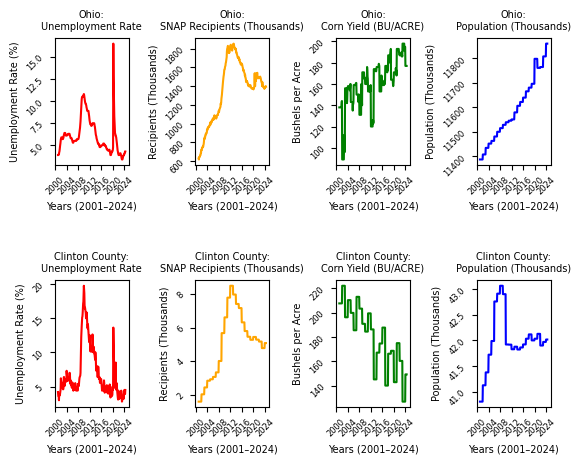

In [19]:
# Univariate trend plots (time series 2001–2024)
#Before plotting pass Observation_Date_Monthly to to_datetime to enable time series plotting
combined_ohio_clinton_df["Observation_Date_Monthly"] = pd.to_datetime(combined_ohio_clinton_df["Observation_Date_Monthly"],  errors="coerce")

#The Trends (Univariate Analysis)
fig1 = plt.figure()
ohio_unem = fig1.add_subplot(2, 4, 1)
ohio_snap = fig1.add_subplot(2, 4, 2)
ohio_corn = fig1.add_subplot(2, 4, 3)
ohio_popu = fig1.add_subplot(2, 4, 4)
clinton_unem = fig1.add_subplot(2, 4, 5)
clinton_snap = fig1.add_subplot(2, 4, 6)
clinton_corn = fig1.add_subplot(2, 4, 7)
clinton_popu = fig1.add_subplot(2, 4, 8)


# Clinton
clinton_unem.plot(
    combined_ohio_clinton_df["Observation_Date_Monthly"],
    combined_ohio_clinton_df["Unemployment_Rate_Clinton"],
    color="red",
    alpha = 1
)
clinton_unem.set_title("Clinton County:\nUnemployment Rate", fontsize=7)
clinton_unem.set_ylabel("Unemployment Rate (%)", fontsize=7)
clinton_unem.set_xlabel("Years (2001–2024)", fontsize=7)
clinton_unem.tick_params(labelsize=6, rotation=45)


clinton_snap.plot(
    combined_ohio_clinton_df["Observation_Date_Monthly"],
    combined_ohio_clinton_df["Number_Of_Snap_Recipients_Clinton"]/1000,
    color="orange",
    alpha = 1
)
clinton_snap.set_title("Clinton County:\nSNAP Recipients (Thousands)", fontsize=7)
clinton_snap.set_ylabel("Recipients (Thousands)", fontsize=7)
clinton_snap.set_xlabel("Years (2001–2024)", fontsize=7)
clinton_snap.tick_params(labelsize=6, rotation=45)


clinton_corn.plot(
    combined_ohio_clinton_df["Observation_Date_Monthly"],
    combined_ohio_clinton_df["Clinton_Corn_Grain_Yield_BU/ACRE"],
    color="green",
    alpha = 1
)
clinton_corn.set_title("Clinton County:\nCorn Yield (BU/ACRE)", fontsize=7)
clinton_corn.set_ylabel("Bushels per Acre", fontsize=7)
clinton_corn.set_xlabel("Years (2001–2024)", fontsize=7)
clinton_corn.tick_params(labelsize=6, rotation=45)


clinton_popu.plot(
    combined_ohio_clinton_df["Observation_Date_Monthly"],
    combined_ohio_clinton_df["Clinton_Population_In_Thousands"],
    color="blue"
)
clinton_popu.set_title("Clinton County:\nPopulation (Thousands)", fontsize=7)
clinton_popu.set_ylabel("Population (Thousands)", fontsize=7)
clinton_popu.set_xlabel("Years (2001–2024)", fontsize=7)
clinton_popu.tick_params(labelsize=6, rotation=45)


# Ohio
ohio_unem.plot(
    combined_ohio_clinton_df["Observation_Date_Monthly"],
    combined_ohio_clinton_df["Unemployment_Rate_Ohio"],
    color="red"
)
ohio_unem.set_title("Ohio:\nUnemployment Rate", fontsize=7)
ohio_unem.set_ylabel("Unemployment Rate (%)", fontsize=7)
ohio_unem.set_xlabel("Years (2001–2024)", fontsize=7)
ohio_unem.tick_params(labelsize=6, rotation=45)


ohio_snap.plot(
    combined_ohio_clinton_df["Observation_Date_Monthly"],
    combined_ohio_clinton_df["Number_Of_Snap_Recipients_Ohio"]/1000,
    color="orange"
)
ohio_snap.set_title("Ohio:\nSNAP Recipients (Thousands)", fontsize=7)
ohio_snap.set_ylabel("Recipients (Thousands)", fontsize=7)
ohio_snap.set_xlabel("Years (2001–2024)", fontsize=7)
ohio_snap.tick_params(labelsize=6, rotation=45)


ohio_corn.plot(
    combined_ohio_clinton_df["Observation_Date_Monthly"],
    combined_ohio_clinton_df["Ohio_Corn_Grain_Yield_BU/ACRE"],
    color="green",
    alpha = 1
)
ohio_corn.set_title("Ohio:\nCorn Yield (BU/ACRE)", fontsize=7)
ohio_corn.set_ylabel("Bushels per Acre", fontsize=7)
ohio_corn.set_xlabel("Years (2001–2024)", fontsize=7)
ohio_corn.tick_params(labelsize=6, rotation=45)


ohio_popu.plot(
    combined_ohio_clinton_df["Observation_Date_Monthly"],
    combined_ohio_clinton_df["Ohio_Population_In_Thousands"],
    color="blue"
)
ohio_popu.set_title("Ohio:\nPopulation (Thousands)", fontsize=7)
ohio_popu.set_ylabel("Population (Thousands)", fontsize=7)
ohio_popu.set_xlabel("Years (2001–2024)", fontsize=7)
ohio_popu.tick_params(labelsize=6, rotation=45)

# Layout spacing
fig1.subplots_adjust(wspace=0.9, hspace= 0.9)



## 2.(c) Univirate trend analysis explanations.
From the graphs, unemployment generally goes up and down. Most notable in around 2008 and 2020 for both Ohio and Clinton County, there is a peak in unemployment. This is likely during economic recession and COVID-19, respectively. For snap benefit, there is a notable peak for both Ohio and Clinton around 2008, and maybe it is likely due to economic recession . The corn yields have been increasing in Ohio since 2001, whilst they have been declining in Ohio since 2001. The population in Ohio has been increasing since 2001; on the other hand, it increased from 2001 to 2008. 

## 2(d). Distribution Analysis, Box Plots

Box plots (whisker plots) summarise the distribution of each variable. All variables use a **6 month lag shift** before plotting, because economic effects such as job losses or changes in SNAP enrollment typically do not appear immediate there is a delay.

The shifted DataFrame `combined_ohio_clinton_shifted_df` is used consistently from this point forward in the analysis. Rows with `NaN` values introduced by the shift are dropped.

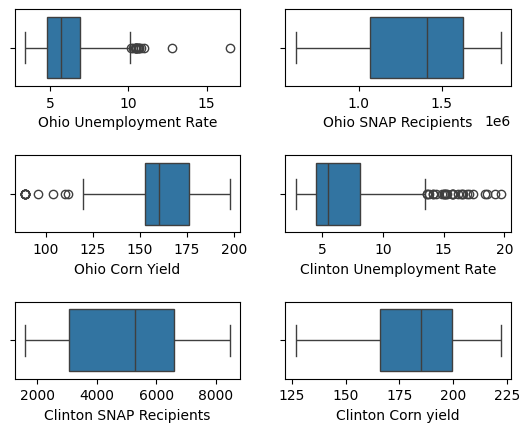

In [20]:
# Apply 6-month lag shift, then plot distributions box plots

# Since the effects are not seen immidiately create a leg of 6 months.
combined_ohio_clinton_df["Unemployment_Rate_Ohio_shifted"] = combined_ohio_clinton_df["Unemployment_Rate_Ohio"].shift(6)
combined_ohio_clinton_df["Number_Of_Snap_Recipients_Ohio_shifted"] = combined_ohio_clinton_df["Number_Of_Snap_Recipients_Ohio"].shift(6)
combined_ohio_clinton_df["Unemployment_Rate_Clinton_shifted"] = combined_ohio_clinton_df["Unemployment_Rate_Clinton"].shift(6)
combined_ohio_clinton_df["Number_Of_Snap_Recipients_Clinton_shifted"] = combined_ohio_clinton_df["Number_Of_Snap_Recipients_Clinton"].shift(6)
combined_ohio_clinton_shifted_df = combined_ohio_clinton_df.dropna()
combined_ohio_clinton_shifted_df = combined_ohio_clinton_shifted_df.reset_index(drop = True)

# Create figure and subplots
fig2 = plt.figure()

# 1. Ohio Unemployment Rate
box_Unemployment_Rate_Ohio = fig2.add_subplot(3, 2, 1)
sns.boxplot(
    data=combined_ohio_clinton_shifted_df, 
    x="Unemployment_Rate_Ohio_shifted", 
    ax=box_Unemployment_Rate_Ohio
)
box_Unemployment_Rate_Ohio.set_xlabel("Ohio Unemployment Rate")


# 2. Ohio SNAP Recipients
box_Number_Of_Snap_Recipients_Ohio = fig2.add_subplot(3, 2, 2)
sns.boxplot(
    data=combined_ohio_clinton_shifted_df, 
    x="Number_Of_Snap_Recipients_Ohio_shifted", 
    ax=box_Number_Of_Snap_Recipients_Ohio
)
box_Number_Of_Snap_Recipients_Ohio.set_xlabel("Ohio SNAP Recipients")
# 3. Ohio Corn Yield
box_Ohio_Corn_Yield = fig2.add_subplot(3, 2, 3)
sns.boxplot(
    data=combined_ohio_clinton_shifted_df, 
    x="Ohio_Corn_Grain_Yield_BU/ACRE", 
    ax=box_Ohio_Corn_Yield
)
box_Ohio_Corn_Yield.set_xlabel("Ohio Corn Yield")
# 4. Clinton Unemployment Rate
box_Unemployment_Rate_Clinton = fig2.add_subplot(3, 2, 4)
sns.boxplot(
    data=combined_ohio_clinton_shifted_df, 
    x="Unemployment_Rate_Clinton_shifted", 
    ax=box_Unemployment_Rate_Clinton
)
box_Unemployment_Rate_Clinton.set_xlabel("Clinton Unemployment Rate")

# 5. Clinton SNAP Recipients
box_Number_Of_Snap_Recipients_Clinton = fig2.add_subplot(3, 2, 5)
sns.boxplot(
    data=combined_ohio_clinton_shifted_df, 
    x="Number_Of_Snap_Recipients_Clinton_shifted", 
    ax=box_Number_Of_Snap_Recipients_Clinton
)
box_Number_Of_Snap_Recipients_Clinton.set_xlabel("Clinton SNAP Recipients")

# 6. Clinton Corn Yield
box_Clinton_Corn_Yield = fig2.add_subplot(3, 2, 6)
sns.boxplot(
    data=combined_ohio_clinton_shifted_df, 
    x="Clinton_Corn_Grain_Yield_BU/ACRE", 
    ax=box_Clinton_Corn_Yield,
)
box_Clinton_Corn_Yield.set_xlabel("Clinton Corn yield")
fig2.subplots_adjust(hspace=0.9, wspace=0.2)

### 2(d) Box Plots explanation 
Ohio unemployment has outliers at around 10% and 16%. These are likely 2008 and 2020 spikes.  The Ohio snap does not have any major outliers. The Ohio corn yield has outliers around 100 bu/acre. Those are likely due to drought years. Clinton's unemployment rate has many outliers and huge spikes of around 15% and 20%. It looks like Clinton might have been greatly affected by 2008 and 2020 more than by Ohio. For both SNAP and corn yields for Clinton, there are no major outliers.

## 2(f). Correlation Matrix

The Pearson correlation matrix shows the pairwise linear relationships between all numeric variables in the combined dataset. Values range from **-1** (perfect negative correlation) to **+1** (perfect positive correlation), with **0** indicating no linear association.

In [21]:
#Pearson correlation matrix across all numeric variables

correlation_matrix = combined_ohio_clinton_shifted_df[["Unemployment_Rate_Ohio_shifted","Number_Of_Snap_Recipients_Ohio_shifted",
                                                       	"Unemployment_Rate_Clinton_shifted","Number_Of_Snap_Recipients_Clinton_shifted"]].corr()
correlation_matrix

,Unemployment_Rate_Ohio_shifted,Number_Of_Snap_Recipients_Ohio_shifted,Unemployment_Rate_Clinton_shifted,Number_Of_Snap_Recipients_Clinton_shifted
Unemployment_Rate_Ohio_shifted,1.000000,0.271978,0.896891,0.304254
Number_Of_Snap_Recipients_Ohio_shifted,0.271978,1.000000,0.477081,0.978973
Unemployment_Rate_Clinton_shifted,0.896891,0.477081,1.000000,0.512031
Number_Of_Snap_Recipients_Clinton_shifted,0.304254,0.978973,0.512031,1.000000


## 2(g). Hypothesis Testing Corn Yield vs. Unemployment and SNAP

**Hypothesis:** There is a statistically significant relationship between corn grain yield and both unemployment rate and SNAP enrollment, in both Ohio and Clinton County.

To test this, Pearson correlation coefficients and their associated **p-values** are computed for four variable pairs:
1. Ohio corn yield vs. Ohio unemployment rate
2. Ohio corn yield vs. Ohio SNAP recipients
3. Clinton corn yield vs. Clinton unemployment rate
4. Clinton corn yield vs. Clinton SNAP recipients

A **p-value < 0.05** indicates the correlation is statistically significant at the 95% confidence level. The scatter plots below display each relationship with a linear regression trendline and the corresponding p-value annotated directly on the chart.

> **Note:** All comparisons use the 6-month lagged values established in Section 5, reflecting the delayed economic response to agricultural changes.

#### Before plotting the correlation graph, we need to drop outliers:
Drop oultilers for unemployemnt, corn yield and snap for bioth clinton and Ohio

In [22]:
corr_data_set = combined_ohio_clinton_shifted_df[
    [
        "Ohio_Corn_Grain_Yield_BU/ACRE",
        "Unemployment_Rate_Ohio_shifted",
        "Number_Of_Snap_Recipients_Ohio_shifted",
        "Clinton_Corn_Grain_Yield_BU/ACRE",
        "Unemployment_Rate_Clinton_shifted",
        "Number_Of_Snap_Recipients_Clinton_shifted"
    ]
]

def drop_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_clean = df[(df[column] >= lower_bound) &(df[column] <= upper_bound)]
    return df_clean
for column in corr_data_set.columns:
    corr_data_set = drop_outliers(corr_data_set, column)
corr_data_set


,Ohio_Corn_Grain_Yield_BU/ACRE,Unemployment_Rate_Ohio_shifted,Number_Of_Snap_Recipients_Ohio_shifted,Clinton_Corn_Grain_Yield_BU/ACRE,Unemployment_Rate_Clinton_shifted,Number_Of_Snap_Recipients_Clinton_shifted
0,138.0,3.9,630057.0,207.6,4.2,1591.0
1,138.0,3.9,618934.0,207.6,3.7,1591.0
2,138.0,3.9,645296.0,207.6,3.6,1591.0
3,139.0,4.0,644531.0,207.6,3.6,1591.0
4,143.0,4.0,648599.0,207.6,3.0,1591.0
...,...,...,...,...,...,...
271,177.0,3.6,1392503.0,149.2,3.6,4775.0
272,177.0,3.8,1392400.0,149.2,3.5,4775.0
273,177.0,3.8,1376833.0,149.2,3.4,4775.0
274,177.0,3.9,1374119.0,149.2,3.2,4775.0


Unemployment rate  and corn yield ohio:
Regression = -0.32754154781658174 and p value = 2.2100611530462183e-07

Snap benefitand Corn yield Ohio:
Regression = 0.2947642855668444 and p value =  3.543923e-06

Unemployment rate and corn yield Clinton:
Regression = 0.11945391719345527 and p value =  6.523597e-02

Snap benefit Ohio and corn yield Clinton:
Regression = -0.5095184685378074 and p value =  3.412318e-17



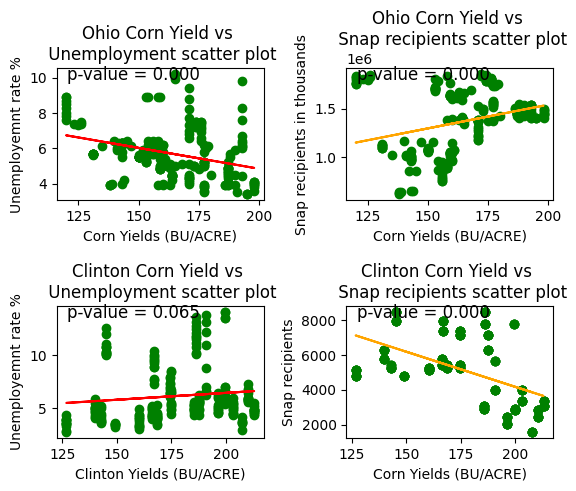

In [23]:
# Hypothesis testing, Pearson r and p-values, then scatter plots

#Ohio 
#First calculate the p value


#Unemployment and corn ohio
regession_oh_u, p_value_oh_u = stats.pearsonr(
    corr_data_set["Ohio_Corn_Grain_Yield_BU/ACRE"], 
    corr_data_set["Unemployment_Rate_Ohio_shifted"])
print("Unemployment rate  and corn yield ohio:")
print(f"Regression = {regession_oh_u} and p value = {p_value_oh_u}")
print()

#Snap Ohio and Corn
regession_oh_s, p_value_oh_s = stats.pearsonr(
    corr_data_set["Ohio_Corn_Grain_Yield_BU/ACRE"], 
    corr_data_set["Number_Of_Snap_Recipients_Ohio_shifted"])
print("Snap benefitand Corn yield Ohio:")
print(f"Regression = {regession_oh_s} and p value = {p_value_oh_s: 2e}")
print()

#Unemployment and corn Clinton
regession_clint_u, p_value_clint_u = stats.pearsonr(
    corr_data_set["Clinton_Corn_Grain_Yield_BU/ACRE"],
    corr_data_set["Unemployment_Rate_Clinton_shifted"],
)
print("Unemployment rate and corn yield Clinton:")
print(f"Regression = {regession_clint_u} and p value = {p_value_clint_u: 2e}")
print()

#Snap Ohio and  and corn yield Clinton
regession_clint_s, p_value_clint_s = stats.pearsonr(
    corr_data_set["Clinton_Corn_Grain_Yield_BU/ACRE"], 
    corr_data_set["Number_Of_Snap_Recipients_Clinton_shifted"])
print("Snap benefit Ohio and corn yield Clinton:")
print(f"Regression = {regession_clint_s} and p value = {p_value_clint_s: 2e}")
print()


#Plots showing corelation significance and p_values
fig3 = plt.figure()
corn_unump_ohio = fig3.add_subplot(2, 2, 1)
corn_unump_ohio.scatter(
    corr_data_set["Ohio_Corn_Grain_Yield_BU/ACRE"],
    corr_data_set["Unemployment_Rate_Ohio_shifted"],
    color = "green"
    );

m1, c1 = np.polyfit(
    corr_data_set["Ohio_Corn_Grain_Yield_BU/ACRE"],
    corr_data_set["Unemployment_Rate_Ohio_shifted"],
    deg= 1,
)
corn_unump_ohio.plot(
    corr_data_set["Ohio_Corn_Grain_Yield_BU/ACRE"],
    corr_data_set["Ohio_Corn_Grain_Yield_BU/ACRE"] * m1 + c1,
    color = "red",
);

corn_unump_ohio.text(
    0.05, 0.95,      
    f"p-value = {p_value_oh_u:.3f}", 
    transform=corn_unump_ohio.transAxes,
    fontsize=12,
    verticalalignment='center'
);
corn_unump_ohio.set_title("Ohio Corn Yield vs \n Unemployment scatter plot")
corn_unump_ohio.set_ylabel("Unemployemnt rate %")
corn_unump_ohio.set_xlabel("Corn Yields (BU/ACRE)")

#Corn Ohio and Snap 
corn_snap_oh = fig3.add_subplot(2, 2, 2)
corn_snap_oh.scatter(
    corr_data_set["Ohio_Corn_Grain_Yield_BU/ACRE"], 
    corr_data_set["Number_Of_Snap_Recipients_Ohio_shifted"],
    color = "green"
);
m2, c2 = np.polyfit(
    corr_data_set["Ohio_Corn_Grain_Yield_BU/ACRE"], 
    corr_data_set["Number_Of_Snap_Recipients_Ohio_shifted"],
    deg = 1
)

corn_snap_oh.plot(
    corr_data_set["Ohio_Corn_Grain_Yield_BU/ACRE"],
    corr_data_set["Ohio_Corn_Grain_Yield_BU/ACRE"]*m2 + c2,
    color = "orange"
    );
corn_snap_oh.text(
    0.05, 0.95,      
    f"p-value = {p_value_oh_s:.3f}", 
    transform=corn_snap_oh.transAxes,
    fontsize=12,
    verticalalignment='center'
);
corn_snap_oh.set_title("Ohio Corn Yield vs \n Snap recipients scatter plot")
corn_snap_oh.set_ylabel("Snap recipients in thousands")
corn_snap_oh.set_xlabel("Corn Yields (BU/ACRE)")

#Clinton unemployment vs Corn
corn_unump_clinton = fig3.add_subplot(2, 2, 3)
corn_unump_clinton.scatter(
    corr_data_set["Clinton_Corn_Grain_Yield_BU/ACRE"],
    corr_data_set["Unemployment_Rate_Clinton_shifted"],
    color = "green"
)

m3, c3 = np.polyfit(
    corr_data_set["Clinton_Corn_Grain_Yield_BU/ACRE"],
    corr_data_set["Unemployment_Rate_Clinton_shifted"],
    deg = 1
)
corn_unump_clinton.plot(
    corr_data_set["Clinton_Corn_Grain_Yield_BU/ACRE"],
    corr_data_set["Clinton_Corn_Grain_Yield_BU/ACRE"] * m3 + c3,
    color = "red"

)
corn_unump_clinton.text(
    0.05, 0.95,      
    f"p-value = {p_value_clint_u:.3f}", 
    transform=corn_unump_clinton.transAxes,
    fontsize=12,
    verticalalignment='center'
);
corn_unump_clinton.set_title("Clinton Corn Yield vs \n Unemployment scatter plot")
corn_unump_clinton.set_ylabel("Unemployemnt rate %")
corn_unump_clinton.set_xlabel("Clinton Yields (BU/ACRE)");

#Clinton Snap and corn
corn_snap_clinton = fig3.add_subplot(2, 2, 4)
corn_snap_clinton.scatter(
    corr_data_set["Clinton_Corn_Grain_Yield_BU/ACRE"], 
    corr_data_set["Number_Of_Snap_Recipients_Clinton_shifted"],
    color = "green"
)

m4, c4 = np.polyfit(
    corr_data_set["Clinton_Corn_Grain_Yield_BU/ACRE"], 
    corr_data_set["Number_Of_Snap_Recipients_Clinton_shifted"],
    deg = 1
)
corn_snap_clinton.plot(
    corr_data_set["Clinton_Corn_Grain_Yield_BU/ACRE"], 
    corr_data_set["Clinton_Corn_Grain_Yield_BU/ACRE"] * m4 + c4,
    color = "orange"
)
corn_snap_clinton.text(
    0.05, 0.95,      
    f"p-value = {p_value_clint_s:.3f}", 
    transform=corn_snap_clinton.transAxes,
    fontsize=12,
    verticalalignment='center'
);
corn_snap_clinton.set_title("Clinton Corn Yield vs \n Snap recipients scatter plot")
corn_snap_clinton.set_ylabel("Snap recipients")
corn_snap_clinton.set_xlabel("Corn Yields (BU/ACRE)");

#Adjust my figure and add tittle
fig3.subplots_adjust(wspace=0.4, hspace=0.8)


## 2(g). Explanations of scatter plots.
There is a negative relationship between Ohio corn yields and unemployment. As corn yields increase, unemployment decreases slightly. The p-value is 0.00, meaning the relationship is significant. On the other hand, the r value is -0.33, suggesting that the linear relationship is weak to moderate. In general, the data might suggest that when more corn is produced in Ohio, unemployment drops slightly. There is a positive relationship between Ohio corn yields and snap. The relationship is significant with a p-value of 0.00, which is surprising because you would expect the opposite of that. The r value is 0.29, suggesting the weakness of the relationship. There is no relationship between the relationship between Clinton corn yield and unemployment, as there is a p-value of 0.065. There is a strong negative relationship between Clinton corn yields and snap with r value of -0.51. The relationship is also significant, with a p-value of 0.00. This means that when Clinton produces more corn, fewer residents need government assistance like SNAP benefits. Overall results show that corn yields play a more positive economic role in Clinton County than Ohio suggests, suggesting that corn yield has the potential to improve the economy in Clinton County, and farmers should invest more in corn production. When we make policies, policies should account for regional differences. 

Explanation of the correlation graph:


## 2(h). Data Aggregation by Time Periods

The following section performs data aggregation by dividing the dataset into five distinct time phases based on years. For each phase, the mean values of key variables are calculated and visualized.

This allows for comparison of average trends across different periods, helping to identify which phase recorded the highest or lowest values for key indicators such as corn yield, unemployment rate, and SNAP participation.

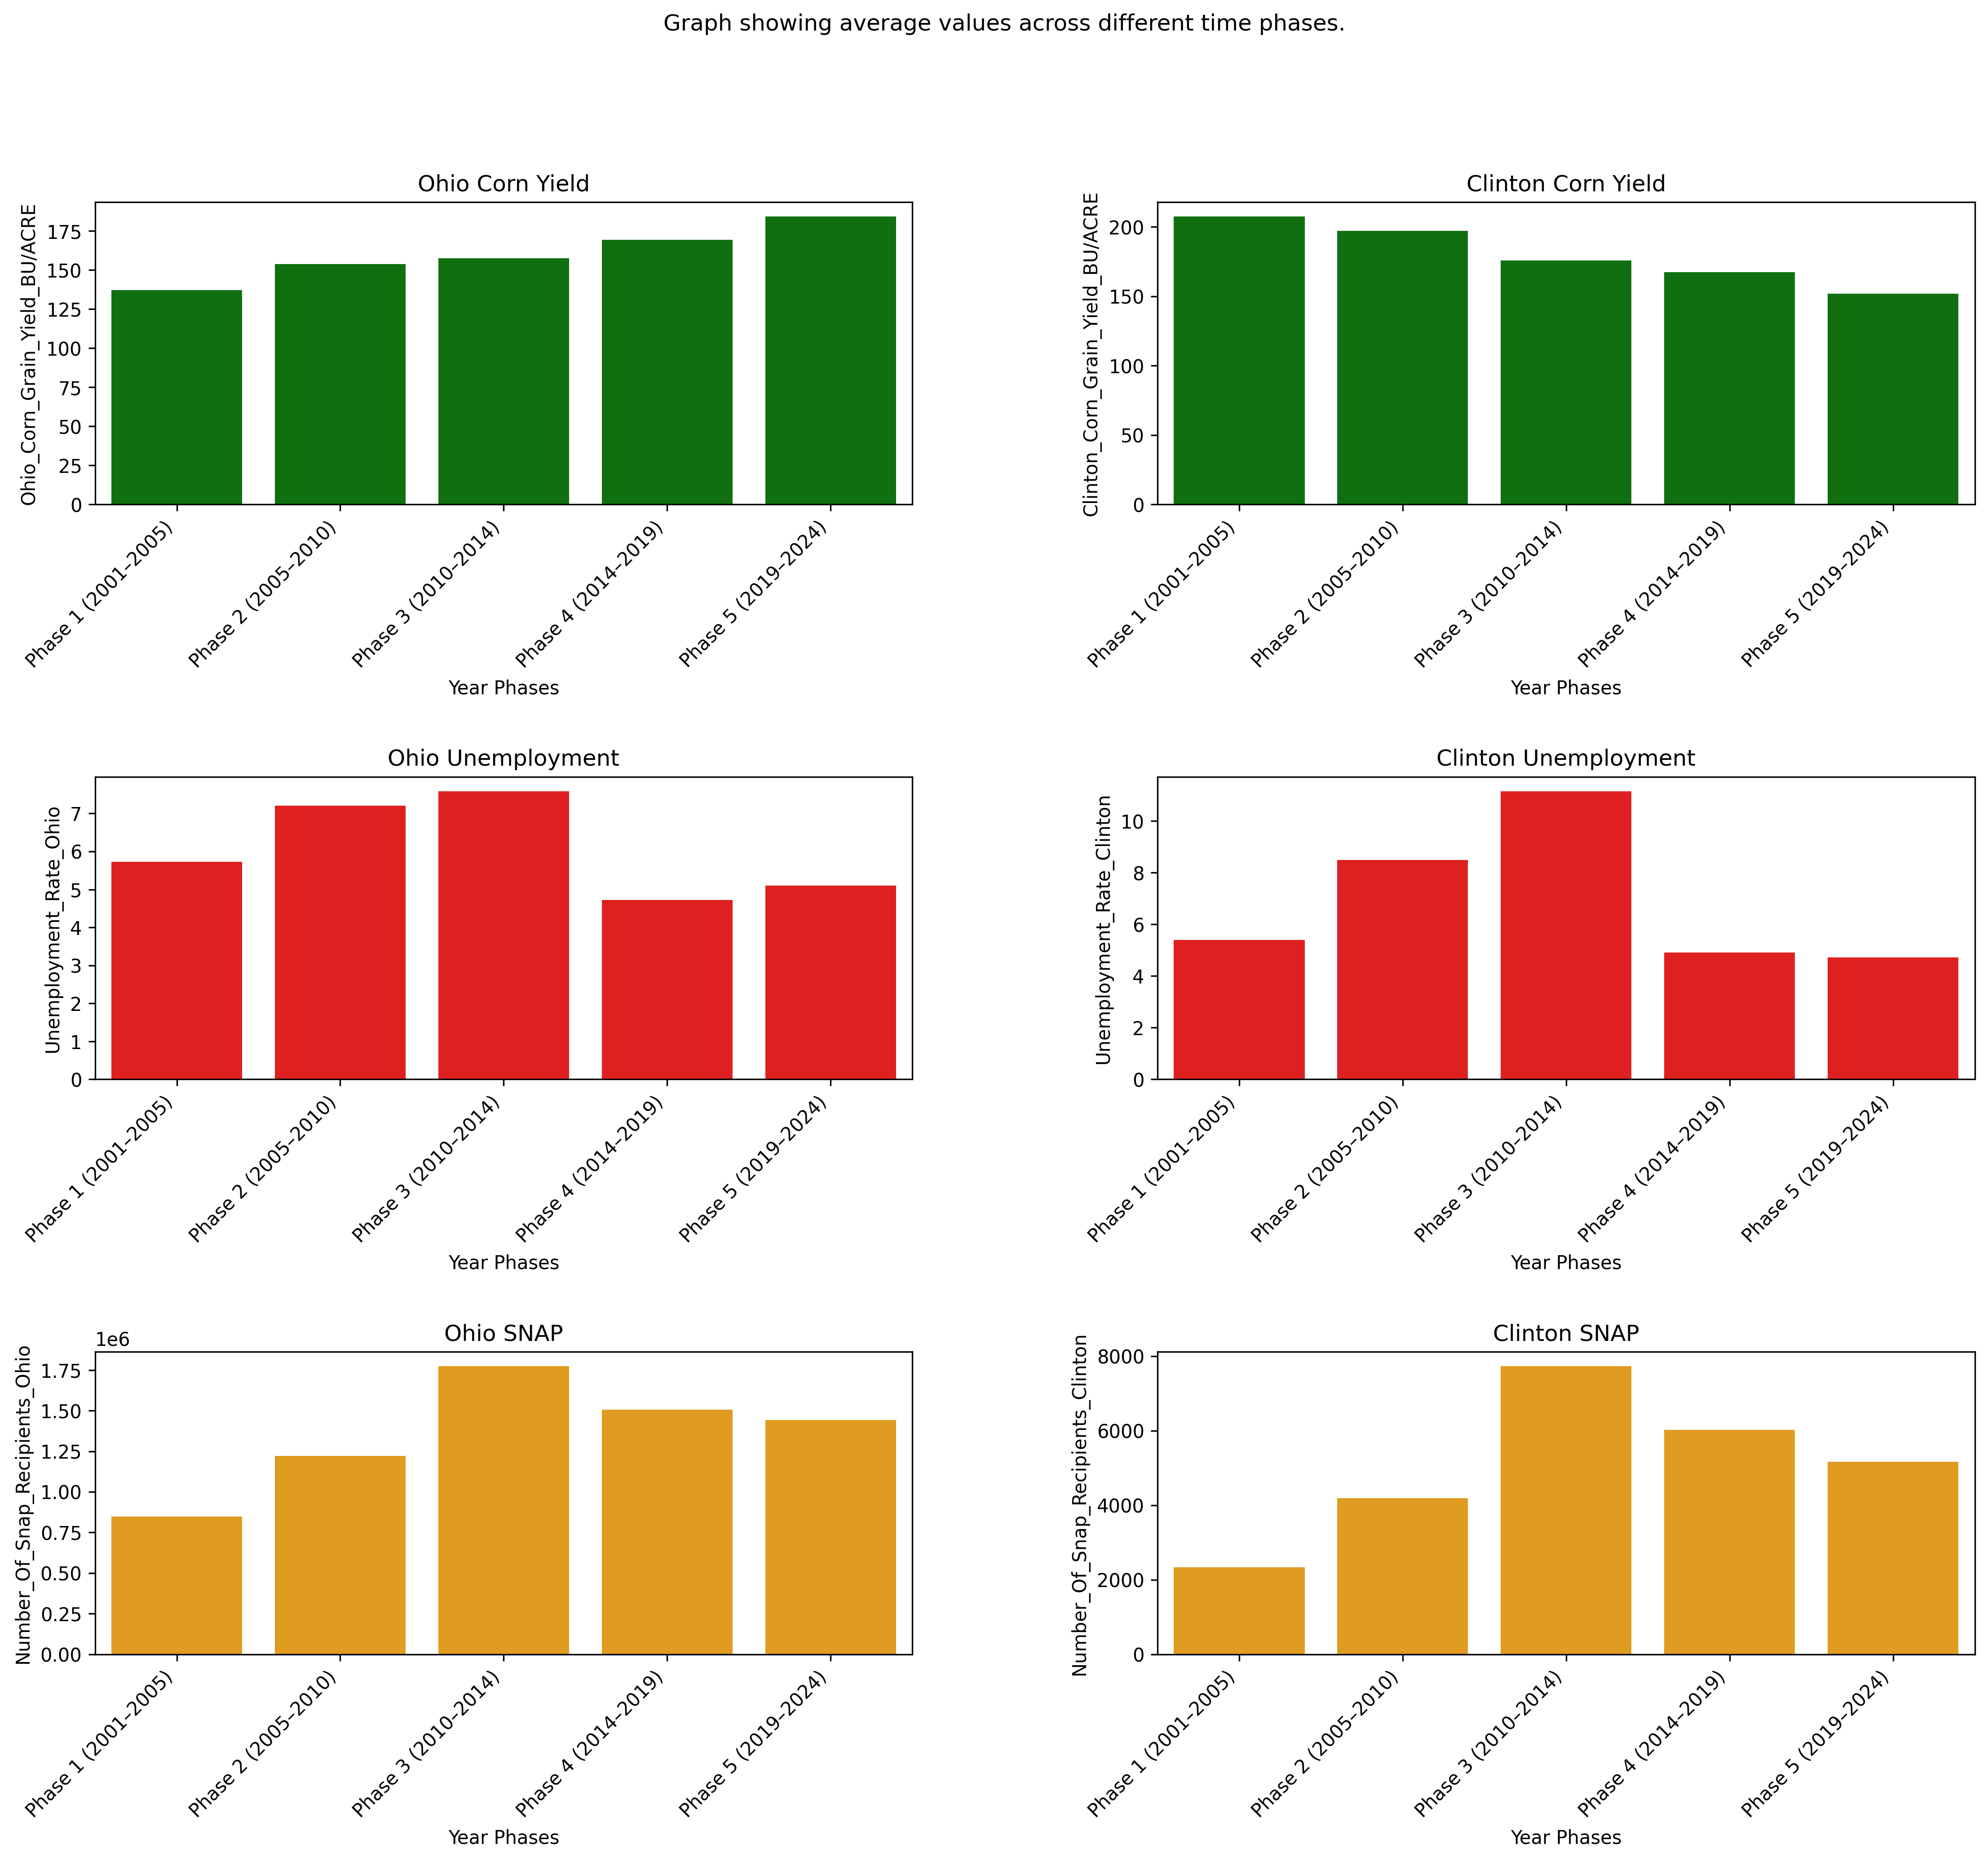

In [24]:
combined_ohio_clinton_df["Year Phases"] = pd.cut(x = combined_ohio_clinton_df["Observation_Date_Monthly"],
                                           bins = 5,  
                                           labels=["Phase 1 (2001–2005)", "Phase 2 (2005–2010)", "Phase 3 (2010–2014)",
                                                   "Phase 4 (2014–2019)", "Phase 5 (2019–2024)"])
combined_ohio_clinton_category = combined_ohio_clinton_df.reset_index(drop = True)
phase_groups = combined_ohio_clinton_category.groupby("Year Phases")[[
                                                                "Ohio_Corn_Grain_Yield_BU/ACRE",
                                                                "Unemployment_Rate_Ohio",
                                                                "Number_Of_Snap_Recipients_Ohio",
                                                                "Clinton_Corn_Grain_Yield_BU/ACRE",
                                                                "Unemployment_Rate_Clinton",
                                                                "Number_Of_Snap_Recipients_Clinton"
                                                        ]].mean()
fig4 = plt.figure(figsize=(18, 14), dpi=300)
# 1. Ohio Corn Yield
corn_yield_ohio = fig4.add_subplot(3, 2, 1)
corn_yield_ohio = sns.barplot(
    data=phase_groups,
    x="Year Phases",
    y="Ohio_Corn_Grain_Yield_BU/ACRE",
    color="green"
)
corn_yield_ohio.set_title("Ohio Corn Yield")
plt.xticks(rotation=45, ha = "right")

# 2. Clinton Corn Yield
corn_yield_clinton = fig4.add_subplot(3, 2, 2)
corn_yield_clinton = sns.barplot(
    data=phase_groups,
    x="Year Phases",
    y="Clinton_Corn_Grain_Yield_BU/ACRE",
    color="green"
)
corn_yield_clinton.set_title("Clinton Corn Yield")
plt.xticks(rotation=45, ha = "right")

# 3. Ohio Unemployment
unemployment_ohio = fig4.add_subplot(3, 2, 3)
unemployment_ohio = sns.barplot(
    data=phase_groups,
    x="Year Phases",
    y="Unemployment_Rate_Ohio",
    color="red"
)
unemployment_ohio.set_title("Ohio Unemployment")
plt.xticks(rotation=45, ha = "right")

# 4. Clinton Unemployment
unemployment_clinton = fig4.add_subplot(3, 2, 4)
unemployment_clinton = sns.barplot(
    data=phase_groups,
    x="Year Phases",
    y="Unemployment_Rate_Clinton",
    color="red"
)
unemployment_clinton.set_title("Clinton Unemployment")
plt.xticks(rotation=45, ha = "right")

# 5. Ohio SNAP
snap_ohio = fig4.add_subplot(3, 2, 5)
snap_ohio = sns.barplot(
    data=phase_groups,
    x="Year Phases",
    y="Number_Of_Snap_Recipients_Ohio",
    color="orange"
)
snap_ohio.set_title("Ohio SNAP")
plt.xticks(rotation=45, ha = "right")

# 6. Clinton SNAP
snap_clinton = fig4.add_subplot(3, 2, 6)
snap_clinton = sns.barplot(
    data=phase_groups,
    x="Year Phases",
    y="Number_Of_Snap_Recipients_Clinton",
    color="orange"
)
snap_clinton.set_title("Clinton SNAP")
plt.xticks(rotation=45, ha = "right")
fig4.suptitle("Graph showing average values across different time phases.");
fig4.subplots_adjust(hspace= 0.9, wspace=0.3)

## 2(h). Data Aggregation by Time Periods explanation.
Each bar shows the average value for that time phase. The average corn yield is increasing in each phase in Ohio, whilst in Clinton County, it is decreasing. Both for Ohio and Clinton, the period from 2010 to 2014 had the highest unemployment  average value, which is likely due to the Great Recession recovery. For both Ohio and Clinton, the snap had a pick in the 2010-2014 phase, which mirrors unemployment, which likely suggests that more people need government after an economic recession. 